Portfolio #1: Exploratory Data Analysis

Dataset Source & Description: I am using the FitLife Health and Fitness Tracking Dataset from Kaggle. This dataset contains detailed information on individuals’ health and fitness metrics, including variables such as age, gender, activity type, workout duration, calories burned, heart rate, sleep, and lifestyle factors like smoking status and stress level. The dataset allows for analysis of how both physiological and behavioral factors influence fitness outcomes. 

Dataset Size: The original dataset contains 687,701 rows and 22 columns. Due to being so large size, I used a random sample of 5000 rows for this analysis to ensure computational efficiency while still maintaining a sufficiently large and representative sample. Guiding 

Research Question:
What fitness and physiological factors are most strongly associated with caloreis burned, and how do workout groups differ in their calorie expenditure?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Where the CSV file is loaded into a panda Dataframe
df = pd.read_csv("health_fitness_dataset.csv")
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


## Section 1 

In [3]:
# Where 'll Create a random sample of 5000 rows for analysis
df_sample = df.sample(n=5000, random_state=42)

# Where I'll Check the shape of the dataset
df_sample.shape

(5000, 22)

Observations: Here I made the dataset sample have 5000 rows and 22 columns. This is a good size to work with because it is large enough for analysis but still easy to manage.

In [4]:
# check data types
df_sample.dtypes

participant_id                int64
date                         object
age                           int64
gender                       object
height_cm                   float64
weight_kg                   float64
activity_type                object
duration_minutes              int64
intensity                    object
calories_burned             float64
avg_heart_rate                int64
hours_sleep                 float64
stress_level                  int64
daily_steps                   int64
hydration_level             float64
bmi                         float64
resting_heart_rate          float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
health_condition             object
smoking_status               object
fitness_level               float64
dtype: object

Observations: 
Based on the sample dataset it contains both numerical and categorical variables. The numerical variables include age, height_cm, weight_kg, duration_minutes, calories_burned, avg_heart_rate, daily_steps, bmi, and others. These variables will be useful for calculating summary statistics and correlations. The categorical variables include gender, activity_type, intensity, and smoking_status. These variables allow me to compare groups and see how different categories behave. One thing I noticed is that the date column is stored as an object instead of a datetime type. But since I am not using time-based analysis, this wont affect my results.


In [5]:
# summary statistics
df_sample.describe()

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1488.234000,41.759800,168.691200,95.307920,70.605200,15.568760,131.47480,7.062120,5.281800,8573.182000,2.480680,22.74156,69.947280,120.018880,80.093800,9.616496
std,863.013619,13.551385,9.199816,22.383419,29.452987,9.986251,17.75678,0.965024,2.771629,2057.356087,0.580016,3.59891,5.061918,9.907362,8.302137,5.466776
min,1.000000,18.000000,145.000000,45.300000,20.000000,1.100000,89.00000,4.000000,1.000000,1649.000000,1.500000,14.20000,51.100000,84.700000,53.700000,0.020000
25%,747.750000,30.000000,161.700000,78.300000,45.000000,8.000000,118.00000,6.400000,3.000000,7148.000000,2.000000,20.07500,66.400000,113.100000,74.600000,5.007500
50%,1476.500000,42.000000,168.000000,95.100000,71.000000,13.200000,130.00000,7.000000,5.000000,8583.000000,2.500000,22.40000,69.900000,120.100000,80.100000,9.650000
75%,2228.500000,54.000000,175.700000,110.800000,97.000000,20.825000,144.00000,7.700000,8.000000,9967.250000,3.000000,25.10000,73.400000,127.000000,85.700000,14.320000
max,3000.000000,64.000000,198.500000,170.000000,120.000000,79.800000,196.00000,10.000000,10.000000,15880.000000,3.500000,36.20000,87.100000,151.800000,112.100000,20.880000


Observations: 
The summary statistics show a wide range in the data, with workout duration from 20 to 120 minutes and calories burned from about 1 to 80. Calories burned appears slightly right-skewed, meaning most values are moderate with a few higher values. I also noticed that the mean calories burned is a little higher than the median, which supports that it is right-skewed. These higher values could act as outliers since they are much larger than most of the data.

In [6]:
df_sample["gender"].value_counts()
df_sample["activity_type"].value_counts()
df_sample["intensity"].value_counts()

intensity
Medium    2469
Low       1511
High      1020
Name: count, dtype: int64

Observations: I see that the categorical variables are fairly well distributed. For example, most workouts are medium intensity, with fewer low and high intensity workouts, but each group still has enough data to compare later.

In [7]:
df_sample.isnull().sum()

participant_id                 0
date                           0
age                            0
gender                         0
height_cm                      0
weight_kg                      0
activity_type                  0
duration_minutes               0
intensity                      0
calories_burned                0
avg_heart_rate                 0
hours_sleep                    0
stress_level                   0
daily_steps                    0
hydration_level                0
bmi                            0
resting_heart_rate             0
blood_pressure_systolic        0
blood_pressure_diastolic       0
health_condition            3548
smoking_status                 0
fitness_level                  0
dtype: int64

In [8]:
# drop the column with lots of missing values
df_sample = df_sample.drop(columns=["health_condition"])

Observations: 
Here I saw that the health_condition column has a large number of missing values, so I removed it from the dataset. Making the data cleaner and prevents missing values from affecting things like correlations or statistical tests later on.

### Section 2: Correlations & Group Comparisons

In [9]:
# correlation matrix
corr_matrix = df_sample.drop(columns=["participant_id"]).corr(numeric_only=True)

corr_matrix

,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
age,1.000000,-0.007800,0.026531,0.002710,0.018084,-0.554885,0.023661,-0.000125,0.012354,-0.011521,0.072698,-0.002842,-0.017859,-0.003952,-0.006680
height_cm,-0.007800,1.000000,0.474683,0.005841,0.181458,0.005610,0.003107,-0.021208,0.011370,-0.006803,0.341736,0.022674,-0.036993,-0.015444,-0.003296
weight_kg,0.026531,0.474683,1.000000,-0.011971,0.357894,-0.035299,0.009827,-0.019462,-0.329960,-0.008845,0.576209,-0.009510,0.000175,-0.009146,0.754748
duration_minutes,0.002710,0.005841,-0.011971,1.000000,0.636673,0.011105,-0.009192,-0.010225,0.011854,-0.012457,-0.010149,-0.019989,0.030380,-0.009830,-0.003400
calories_burned,0.018084,0.181458,0.357894,0.636673,1.000000,0.109421,-0.025072,-0.012970,-0.103140,-0.017571,0.212386,-0.016494,0.015477,-0.008360,0.267909
avg_heart_rate,-0.554885,0.005610,-0.035299,0.011105,0.109421,1.000000,-0.024735,-0.001809,0.015545,0.009223,-0.042809,0.012700,0.013328,-0.000277,-0.020658
hours_sleep,0.023661,0.003107,0.009827,-0.009192,-0.025072,-0.024735,1.000000,0.000133,-0.038393,0.002134,-0.010391,-0.001855,-0.011291,-0.015860,0.018506
stress_level,-0.000125,-0.021208,-0.019462,-0.010225,-0.012970,-0.001809,0.000133,1.000000,0.013197,0.036238,-0.005602,-0.001436,0.007994,0.008935,-0.014871
daily_steps,0.012354,0.011370,-0.329960,0.011854,-0.103140,0.015545,-0.038393,0.013197,1.000000,0.000746,0.013904,-0.003642,0.005622,0.017335,-0.445633
hydration_level,-0.011521,-0.006803,-0.008845,-0.012457,-0.017571,0.009223,0.002134,0.036238,0.000746,1.000000,-0.008258,-0.008381,-0.003204,-0.029398,-0.004173


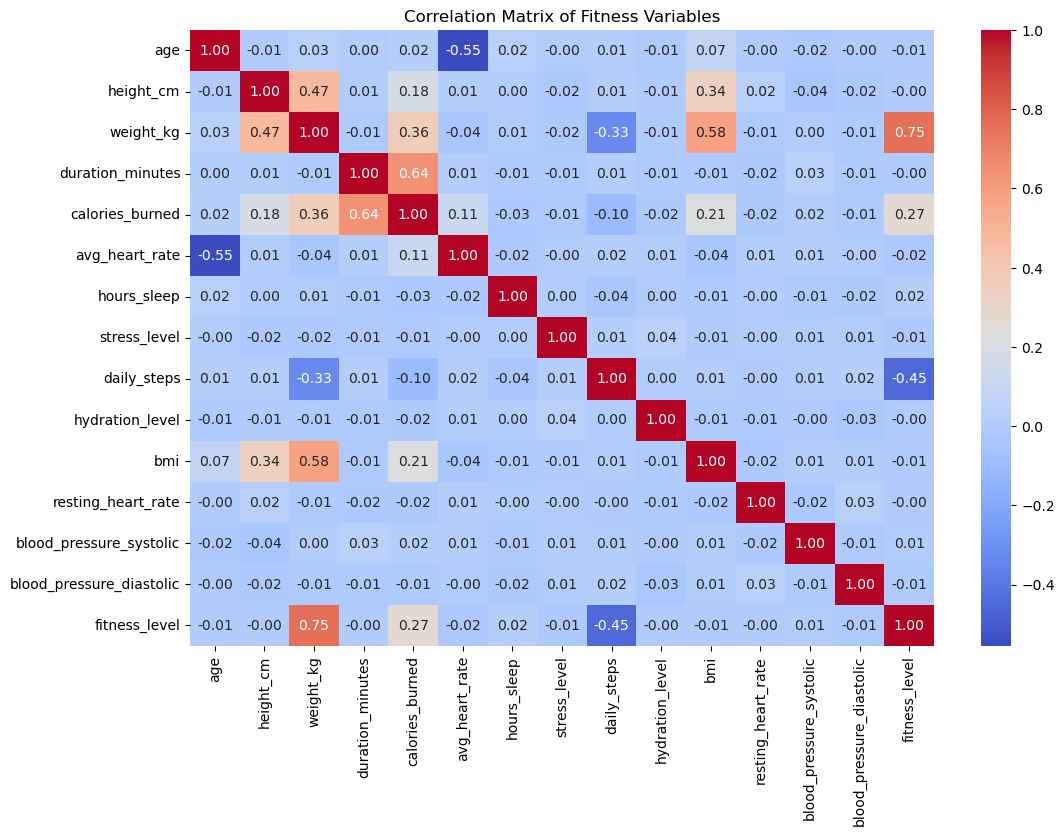

In [10]:
# heatmap of correlations
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Fitness Variables")
plt.show()

Observations: 
From the heatmap, I can see that calories burned has the strongest positive relationship with duration (r ≈ 0.64), meaning longer workouts tend to burn more calories. There is also a moderate relationship between calories burned and weight (r ≈ 0.36), suggesting body weight may also affect calorie expenditure. Another interesting pattern is that age has a strong negative relationship with average heart rate (r ≈ -0.55), showing that older individuals tend to have lower heart rates during activity. Overall though, duration_minutes and weight_kg appear to be the most important variables when explaining calories burned. 

In [11]:
# average calories burned by activity type
df_sample.groupby("activity_type")["calories_burned"].mean().sort_values(ascending=False)

activity_type
HIIT               25.335484
Running            22.377172
Cycling            18.601002
Basketball         17.334756
Tennis             15.773242
Swimming           14.953542
Weight Training    13.478039
Dancing            12.043673
Walking             8.581818
Yoga                6.697260
Name: calories_burned, dtype: float64

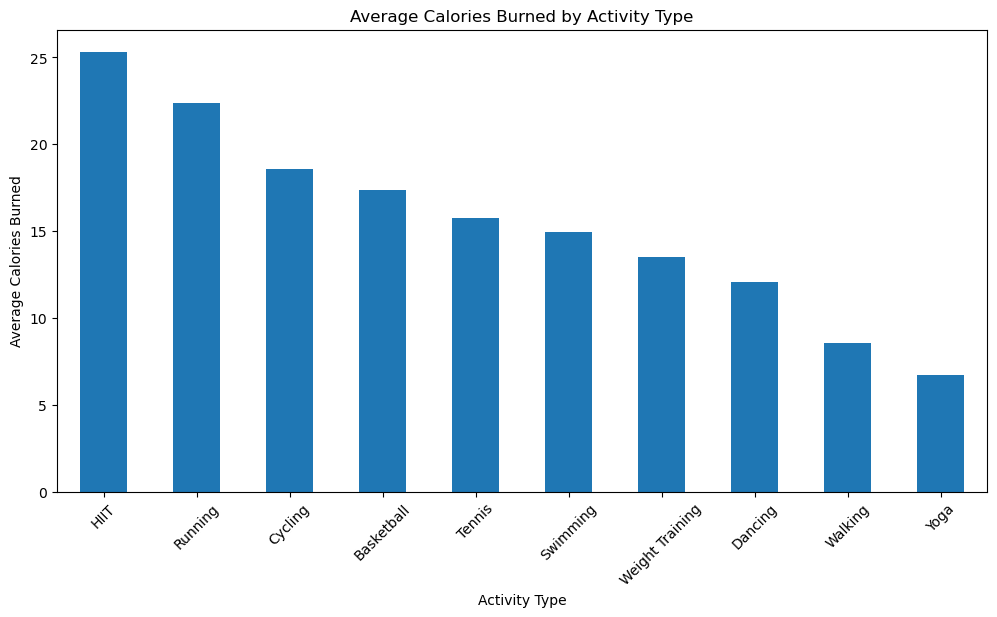

In [12]:
# bar chart of average calories burned by activity type
plt.figure(figsize=(12,6))

df_sample.groupby("activity_type")["calories_burned"].mean().sort_values(ascending=False).plot(kind="bar")

plt.title("Average Calories Burned by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)

plt.show()

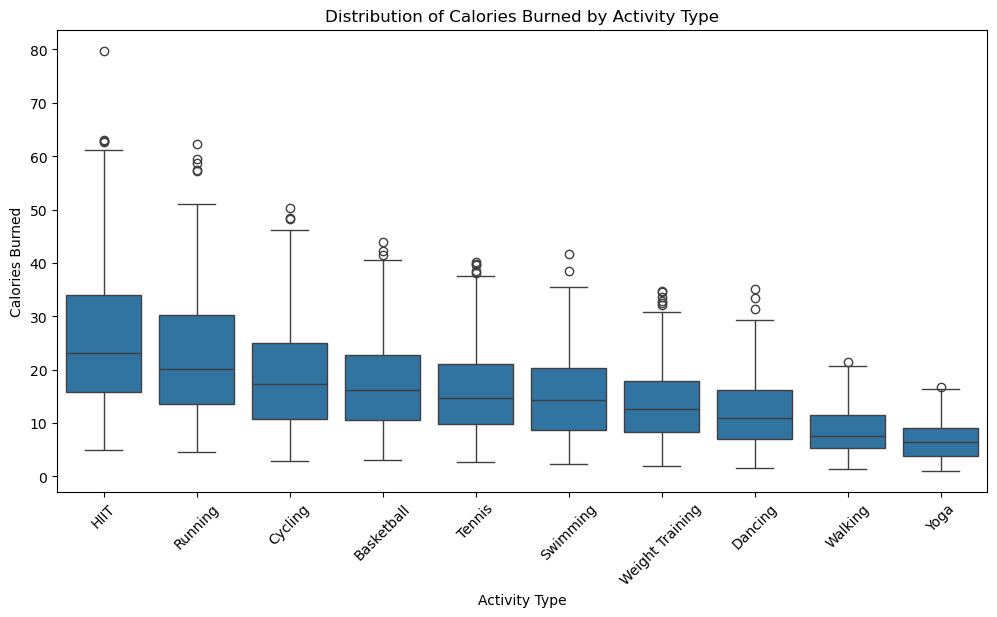

In [13]:
# boxplot of calories burned by activity type
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_sample,
    x="activity_type",
    y="calories_burned",
    order=["HIIT", "Running", "Cycling", "Basketball", "Tennis", "Swimming", "Weight Training", "Dancing", "Walking", "Yoga"]
)

plt.title("Distribution of Calories Burned by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Calories Burned")
plt.xticks(rotation=45)

plt.show()

Group Comparison Analysis:

To compare workout groups, I looked at the average calories burned for each activity type. HIIT had the highest average calories burned, followed by running and cycling, while yoga and walking had the lowest averages. This makes sense because higher intensity workouts usually require more energy. Additionally from the boxplot, I also noticed that some activities like HIIT and running have a wider spread of values and more outliers, meaning calorie burn can vary more depending on effort. Lower intensity workouts like walking and yoga are more concentrated at lower values, showing they are more consistent but burn fewer calories overall.


### SECTION 3: Advanced Visualizations:

#1 Pairplot

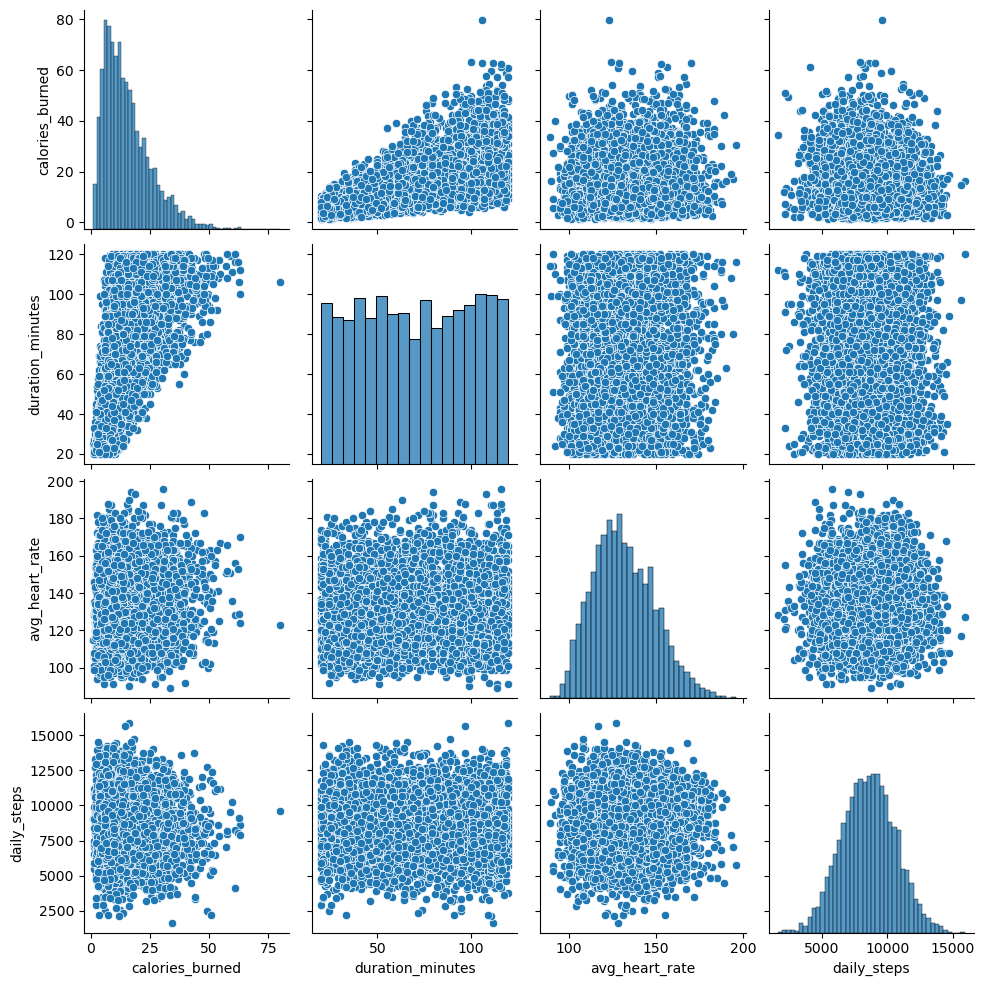

In [14]:
# Sample for speed (dataset is huge)

sns.pairplot(df_sample[[
    "calories_burned",
    "duration_minutes",
    "avg_heart_rate",
    "daily_steps"
]])

plt.show()

### Pair Plot Analysis:

I used a pair plot to look at the relationships between multiple numerical variables at the same time. From the visualizations shown, I noticed that calories burned and duration_minutes have a clear positive relationship, which makes sense because longer workouts burn more calories. I also noticed that some variables like avg_heart_rate and daily_steps do not show strong linear relationships with calories burned, since the points are more spread out with no clear pattern. Suggesting that these variables may not be as important in predicting calories burned compared to duration. All in all, this visualization helps confirm which variables have strong relationships and which ones do not, especially in a way that is easier to see than just looking at numbers in a correlation table.


#2 Violin Plot 

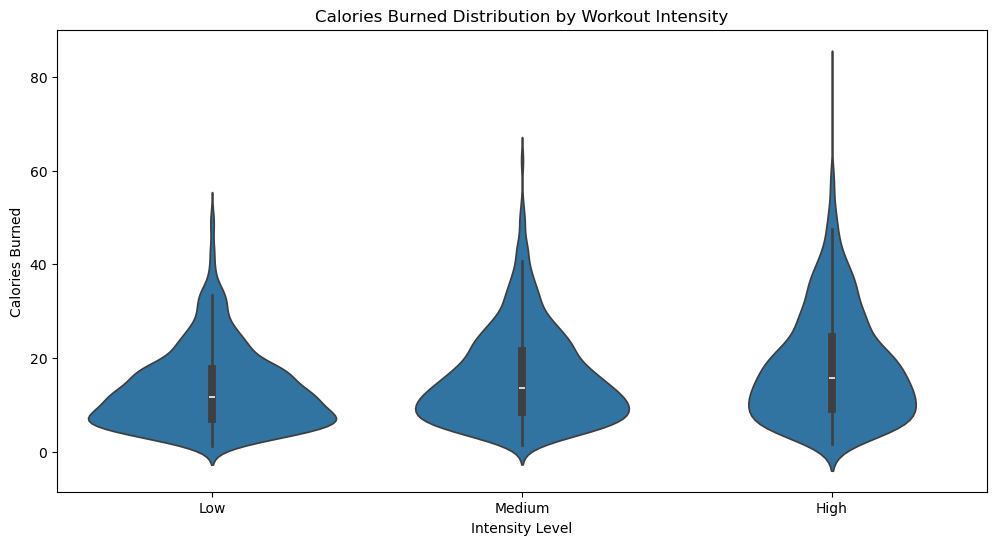

In [15]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_sample,
    x="intensity",
    y="calories_burned",
    order=["Low", "Medium", "High"]  # THIS is where order goes
)

plt.title("Calories Burned Distribution by Workout Intensity")
plt.xlabel("Intensity Level")
plt.ylabel("Calories Burned")

plt.show()

#Violin Plot Analysis:

I used a violin plot to compare how calories burned changes across different workout intensity levels. From this graph, I noticed that high intensity workouts tend to burn more calories and also have a wider spread of values. This means there is more variation, but overall higher calorie burn. Medium intensity workouts fall in the middle, while low intensity workouts are more concentrated at lower calorie values. This makes sense to me because higher intensity workouts require more effort and energy, which leads to more calories burned. I also noticed that the distributions get wider as intensity increases, showing that higher intensity workouts not only burn more calories but also have a bigger range of outcomes. Overall, the violin plots show that workout intensity plays a big role in calorie expenditure.

#3 Regression Plot

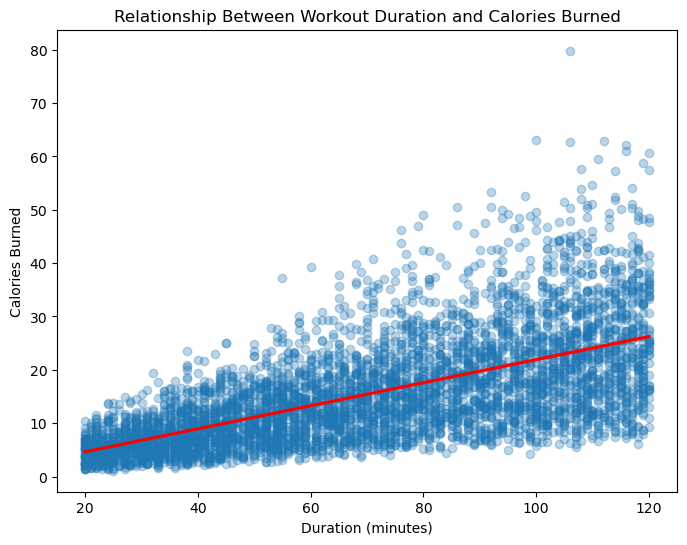

In [16]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_sample,
    x="duration_minutes",
    y="calories_burned",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Workout Duration and Calories Burned")
plt.xlabel("Duration (minutes)")
plt.ylabel("Calories Burned")

plt.show()

#Regresion Plot Analysis:

Here I used a regression plot to better understand the relationship between workout duration and calories burned. From the graph, I can clearly see an upward trend, meaning that as workout duration increases, calories burned also increases. The red line makes this relationship easier to see, showing a positive linear trend between the two variables. However, I also noticed that the data points are somewhat spread out around the line, which means there is still variability. This suggests that while duration is a major factor, other variables like intensity or activity type also play a role. All in all, this confirms what I had observed earlier in the correlation and pair plot that duration is one of the main factors affecting calories burned.

## Section 4: Hypothesis Testing

### Test 1: Correlation Between Duration and Calories Burned

I want to test whether there is a real relationship between workout duration and calories burned.

H₀ (null hypothesis): There is no relationship between duration_minutes and calories_burned.

H₁ (alternative hypothesis): There is a relationship between duration_minutes and calories_burned.

I am using a Pearson correlation test because both variables are numerical and I want to test if the relationship is statistically significant.

I will use a significance level of α = 0.05.

In [17]:
from scipy import stats

r, p_value = stats.pearsonr(df_sample["duration_minutes"], df_sample["calories_burned"])

print("Pearson r:", r)
print("p-value:", p_value)

Pearson r: 0.63667283675001
p-value: 0.0


### Interpretation (Test 1)

The pvalue is extremely small and less than 0.05, so I reject the null hypothesis. This means there is a statistically significant relationship between workout duration and calories burned. The Pearson correlation value is about 0.64, which shows a moderately strong positive relationship. This means that as workout duration increases, calories burned also tends to increase. This matches what I saw earlier in the visualizations, especially in the regression plot where there was a clear upward trend. One thing to note is that the dataset is large, so even smaller relationships can appear statistically significant.


### Test 2: Calories Burned for High vs Low Intensity Workouts

Now I want to test whether high intensity workouts burn more calories than low intensity workouts.

H₀ (null hypothesis): The average calories burned is the same for high and low intensity workouts.

H₁ (alternative hypothesis): The average calories burned is different between high and low intensity workouts.

I am using a two-sample t-test because I am comparing the means of two groups.

I will also use a significance level of α = 0.05.

In [18]:
# This test compares the average calories burned between high intensity and low intensity workouts

high = df_sample[df_sample["intensity"] == "High"]["calories_burned"]
low = df_sample[df_sample["intensity"] == "Low"]["calories_burned"]
t_stat, p_value = stats.ttest_ind(high, low)

print("t-statistic:", t_stat)
print(f"p-value: {p_value:.6f}")

t-statistic: 12.199378378984873
p-value: 0.000000


### Interpretation (Test 2)

The pvalue is extremely small and less than 0.05, so I’m going to reject the null hypothesis. This means there is a statistically significant difference in calories burned between high and low intensity workouts. The t statistic is about 12.2 showing that the difference between the two groups is strong. This matches what I saw earlier in the violin plot, where high intensity workouts clearly burned more calories than low intensity workouts. One limitation is that this test only compares intensity and does not consider other factors like workout duration, which could also affect calories burned. Also, since the dataset is large, even small differences can appear statistically significant. This means we have enough evidence to conclude that the average calories burned is different between high and low intensity workouts.


### SECTION 5: Final EDA Summary


### 1. Summary of Major Findings
 Overall, this EDA helped me better understand what factors are most related to calories burned. The clearest pattern I found was that workout duration has the strongest relationship with calories burned. In both the correlation analysis and the regression plot, duration_minutes showed a clear positive relationship with calories_burned, which means that longer workouts usually lead to more calories burned. Weight also has a moderate positive relationship with calories burned, which suggests that body weight may also affect how much energy a person uses during exercise. From the group comparisons, I found that workout type and workout intensity both matter a lot. HIIT had the highest average calories burned, followed by running and cycling, while yoga and walking had the lowest averages. The violin plot and boxplot also showed that higher intensity workouts not only burn more calories on average, but also have a wider spread of values. This means that high intensity workouts can vary more, but they still tend to lead to higher calorie burn overall. The hypothesis tests supported what I saw in the visualizations. The Pearson correlation test showed a statistically significant positive relationship between workout duration and calories burned, with a correlation of about 0.64. This matched the upward trend I saw in the regression plot and pair plot. The two-sample t-test also showed a statistically significant difference between high and low intensity workouts, which supports what I saw in the violin plot. Overall, the results from the tests and the graphs were consistent with each other and helped confirm the main patterns in the data. 

### 2. Limitations and Caveats
 There are definitely some limitations in this dataset that are important to keep in mind. First, even though the original dataset was very large, I used a random sample of 5000 rows for my analysis. This was done to make the analysis more manageable, but it still means my results are based on a sample rather than the full dataset. Also, since the dataset came from Kaggle, I do not know all the details about how the data was originally collected or whether it fully represents a real population. Because of that, the conclusions may not apply equally to everyone. Another limitation is that the health_condition column had a large number of missing values, so I removed it from the analysis. This helped make the dataset cleaner, but it also means I could not explore whether health conditions affect workout outcomes. I also noticed that the date column was stored as an object instead of a datetime variable. That did not affect my current analysis, but it would matter if I wanted to study trends over time. Another one is that the dataset is large enough that even smaller relationships can come out as statistically significant. Because of that, it is important to look at both the p-values and the actual size of the relationships. In this project, I tried to do that by connecting the hypothesis tests to the plots and correlation values instead of relying only on significance. 

### 3. Next Steps 

If I were to continue this analysis, I would want to explore more variables that could affect calories burned at the same time instead of looking at them mostly one by one. For example, I would want to see how workout duration, intensity, activity type, weight, and heart rate work together. I would also want to convert the date column into a datetime format so I could check whether there are patterns over time. It would also be helpful to collect more detailed variables that are not included here, such as workout pace, distance covered, body fat percentage, metabolism-related information, or fitness goals. These could help explain why some people burn more calories than others even when doing similar workouts. Yes, I do think this dataset could be used for a predictive model. A good next step would be to build a model that predicts calories burned based on variables like duration_minutes, activity_type, intensity, weight_kg, and avg_heart_rate. That would make sense because calories burned is the main outcome I focused on in this project, and the analysis already showed that several of these variables are meaningfully related to it.
